In [17]:
# ============================================
# MODÉLISATION AVANCÉE - ANALYSE DES ERREURS
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, KFold, RandomizedSearchCV
from sklearn.metrics import mean_squared_log_error, r2_score, make_scorer
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, VotingRegressor, StackingRegressor
from sklearn.linear_model import Ridge
import xgboost as xgb
import joblib
import warnings
warnings.filterwarnings('ignore')

print("=" * 70)
print("🚀 MODÉLISATION AVANCÉE - ANALYSE DES ERREURS")
print("=" * 70)

# 1. CHARGEMENT
print("\n📂 1. CHARGEMENT DES DATASETS")
print("-" * 50)

df_train = pd.read_csv('../data/train.csv')
df_test = pd.read_csv('../data/test.csv')

print(f"✅ Train: {df_train.shape[0]} lignes, {df_train.shape[1]} colonnes")
print(f"✅ Test: {df_test.shape[0]} lignes, {df_test.shape[1]} colonnes")

🚀 MODÉLISATION AVANCÉE - ANALYSE DES ERREURS

📂 1. CHARGEMENT DES DATASETS
--------------------------------------------------
✅ Train: 1153 lignes, 36 colonnes
✅ Test: 289 lignes, 33 colonnes


In [18]:
# ============================================
# ÉTAPE 1: FEATURE ENGINEERING AVANCÉ
# ============================================

print("\n" + "=" * 70)
print("🔧 ÉTAPE 1: FEATURE ENGINEERING AVANCÉ")
print("=" * 70)

# 1.1 Features temporelles
df_train['date_publication'] = pd.to_datetime(df_train['date_publication'])
df_train['mois'] = df_train['date_publication'].dt.month
df_train['trimestre'] = df_train['date_publication'].dt.quarter
df_train['annee'] = df_train['date_publication'].dt.year


# 1.3 Interactions géographiques
df_train['pois_density_centre'] = df_train['nb_total_pois_1km'] / (df_train['dist_centre_ville_km'] + 0.1)
df_train['pois_density_plage'] = df_train['nb_total_pois_1km'] / (df_train['dist_plage_km'] + 0.1)
df_train['centre_x_plage'] = df_train['dist_centre_ville_km'] * df_train['dist_plage_km']

# 1.4 Score d'équipement
df_train['score_equipement'] = (df_train['has_garage'] + df_train['has_jardin'] + 
                                df_train['has_piscine'] + df_train['has_balcon'] + 
                                df_train['has_meuble'] + df_train['has_titre_foncier'])


# 1.6 Encodage type_bien
type_dummies = pd.get_dummies(df_train['type_bien'], prefix='type', drop_first=True)
df_train = pd.concat([df_train, type_dummies], axis=1)

# 1.7 Statistiques par quartier (sans prix!)
quartier_stats = df_train.groupby('quartier').agg({
    'surface_m2': 'mean',
    'nb_pieces_total': 'mean',
    'nb_total_pois_1km': 'mean',
    'age_annonce': 'mean'
}).round(2)
quartier_stats.columns = ['surface_moy_quartier', 'pieces_moy_quartier', 
                          'pois_moy_quartier', 'age_moy_quartier']
df_train = df_train.merge(quartier_stats, on='quartier', how='left')

print(f"✅ {len(df_train.columns) - 36} nouvelles features créées")


🔧 ÉTAPE 1: FEATURE ENGINEERING AVANCÉ
✅ 17 nouvelles features créées


In [19]:
# ============================================
# ÉTAPE 2: SÉLECTION DES FEATURES
# ============================================

print("\n" + "=" * 70)
print("🎯 ÉTAPE 2: SÉLECTION DES FEATURES")
print("=" * 70)

target = 'prix'

cols_to_exclude = [
    'id', 'prix', 'log_prix', 'prix_m2',  # cibles
    'titre', 'description', 'caracteristiques', 'adresse_osm', 'source',
    'date_publication', 'quartier', 'type_bien'
]

feature_cols = [col for col in df_train.columns 
                if col not in cols_to_exclude 
                and col in df_train.columns 
                and df_train[col].dtype in ['int64', 'float64']]

print(f"\n✅ {len(feature_cols)} features sélectionnées")

X = df_train[feature_cols]
y = df_train[target]

print(f"📊 X shape: {X.shape}")


🎯 ÉTAPE 2: SÉLECTION DES FEATURES

✅ 32 features sélectionnées
📊 X shape: (1153, 32)


In [20]:
# ============================================
# ÉTAPE 3: SPLIT AVEC STRATIFICATION
# ============================================

from sklearn.model_selection import StratifiedShuffleSplit

# Créer des bins de prix pour la stratification
df_train['prix_bin'] = pd.cut(df_train['prix'], 
                               bins=[0, 2e6, 5e6, 10e6, 20e6, 50e6],
                               labels=[1,2,3,4,5])

split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_idx, val_idx in split.split(X, df_train['prix_bin']):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

print(f"✅ Train: {len(X_train)}")
print(f"✅ Validation: {len(X_val)}")

✅ Train: 922
✅ Validation: 231


In [21]:
# ============================================
# ÉTAPE 4: MODÈLES AVEC VALIDATION CROISÉE
# ============================================

print("\n" + "=" * 70)
print("🤖 ÉTAPE 4: ENTRAÎNEMENT DES MODÈLES")
print("=" * 70)

def rmsle(y_true, y_pred):
    y_pred = np.maximum(y_pred, 0)
    return np.sqrt(np.mean((np.log1p(y_pred) - np.log1p(y_true)) ** 2))

# Modèles avec hyperparamètres optimisés
models = {
    'RF': RandomForestRegressor(
        n_estimators=300, max_depth=20, min_samples_split=5,
        random_state=42, n_jobs=-1
    ),
    'GB': GradientBoostingRegressor(
        n_estimators=300, learning_rate=0.05, max_depth=5,
        subsample=0.8, random_state=42
    ),
    'XGB': xgb.XGBRegressor(
        n_estimators=300, learning_rate=0.05, max_depth=5,
        subsample=0.8, colsample_bytree=0.8, random_state=42
    )
}

results = {}
predictions_val = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    score = rmsle(y_val, y_pred)
    results[name] = score
    predictions_val[name] = y_pred
    print(f"✅ {name}: {score:.4f}")


🤖 ÉTAPE 4: ENTRAÎNEMENT DES MODÈLES
✅ RF: 0.5960
✅ GB: 0.6235
✅ XGB: 0.6210


In [22]:
# ============================================
# ÉTAPE 5: ANALYSE APPROFONDIE DES ERREURS
# ============================================

print("\n" + "=" * 70)
print("🔍 ÉTAPE 5: ANALYSE DES ERREURS")
print("=" * 70)

# Prendre le meilleur modèle
best_model_name = min(results, key=results.get)
best_model = models[best_model_name]
best_pred = predictions_val[best_model_name]

# DataFrame d'analyse
error_analysis = pd.DataFrame({
    'prix_reel': y_val.values,
    'prix_pred': best_pred,
    'erreur_abs': np.abs(y_val.values - best_pred),
    'erreur_pct': np.abs(y_val.values - best_pred) / y_val.values * 100,
    'quartier': df_train.loc[y_val.index, 'quartier'].values,
    'type_bien': df_train.loc[y_val.index, 'type_bien'].values,
    'surface': df_train.loc[y_val.index, 'surface_m2'].values,
})

print("\n📊 STATISTIQUES GLOBALES:")
print(f"Erreur moyenne: {error_analysis['erreur_abs'].mean():,.0f} MRU")
print(f"Erreur médiane: {error_analysis['erreur_abs'].median():,.0f} MRU")
print(f"Erreur % moyenne: {error_analysis['erreur_pct'].mean():.1f}%")


🔍 ÉTAPE 5: ANALYSE DES ERREURS

📊 STATISTIQUES GLOBALES:
Erreur moyenne: 1,641,523 MRU
Erreur médiane: 819,312 MRU
Erreur % moyenne: 58.8%


In [23]:
# ============================================
# ÉTAPE 5b: ANALYSE PAR CATÉGORIE
# ============================================

# 1. Par quartier
print("\n🏘️ ERREUR PAR QUARTIER:")
quartier_errors = error_analysis.groupby('quartier').agg({
    'erreur_pct': 'mean',
    'prix_reel': 'count'
}).round(1).sort_values('erreur_pct', ascending=False)
print(quartier_errors)

# 2. Par type de bien
print("\n🏠 ERREUR PAR TYPE DE BIEN:")
type_errors = error_analysis.groupby('type_bien').agg({
    'erreur_pct': 'mean',
    'prix_reel': 'count'
}).round(1).sort_values('erreur_pct', ascending=False)
print(type_errors)

# 3. Par tranche de prix
error_analysis['tranche_prix'] = pd.cut(error_analysis['prix_reel'], 
                                         bins=[0, 2e6, 5e6, 10e6, 20e6, 50e6],
                                         labels=['<2M', '2-5M', '5-10M', '10-20M', '>20M'])
print("\n💰 ERREUR PAR TRANCHE DE PRIX:")
prix_errors = error_analysis.groupby('tranche_prix')['erreur_pct'].mean().round(1)
print(prix_errors)




🏘️ ERREUR PAR QUARTIER:
               erreur_pct  prix_reel
quartier                            
dar naim             88.3         21
arafat               71.1         46
riyadh               63.9          3
toujounine           60.5         31
teyarett             56.6         46
tevragh zeina        46.6         79
ksar                 22.2          4
sebkha               15.0          1

🏠 ERREUR PAR TYPE DE BIEN:
             erreur_pct  prix_reel
type_bien                         
terrain            90.1          6
studio             70.6          1
maison             65.4        173
appartement        54.5          1
duplex             34.0         42
villa              22.7          8

💰 ERREUR PAR TRANCHE DE PRIX:
tranche_prix
<2M       94.7
2-5M      36.5
5-10M     27.0
10-20M    35.7
>20M      52.3
Name: erreur_pct, dtype: float64



🔴 TOP 20 DES PIRES PRÉDICTIONS:
     prix_reel     prix_pred  erreur_pct       quartier type_bien
118   275200.0  1.898749e+06  589.952328       dar naim    maison
202  1005000.0  6.513995e+06  548.158667  tevragh zeina    maison
223   275200.0  1.458672e+06  430.040795         arafat    maison
7     600000.0  3.029461e+06  404.910164         arafat    maison
185   550000.0  2.654781e+06  382.687500       teyarett    maison
193   300000.0  1.419616e+06  373.205195         arafat    maison
182   400000.0  1.811526e+06  352.881455       teyarett    duplex
100  1800000.0  6.772516e+06  276.250902  tevragh zeina    maison
151  1500000.0  5.437598e+06  262.506542  tevragh zeina    maison
12    350000.0  1.206108e+06  244.602346       teyarett    maison
152  1600000.0  5.461959e+06  241.372457       dar naim    maison
145   700000.0  2.297634e+06  228.233378       teyarett    maison
61    420000.0  1.179515e+06  180.836797     toujounine   terrain
3     350000.0  9.790527e+05  179.729329   

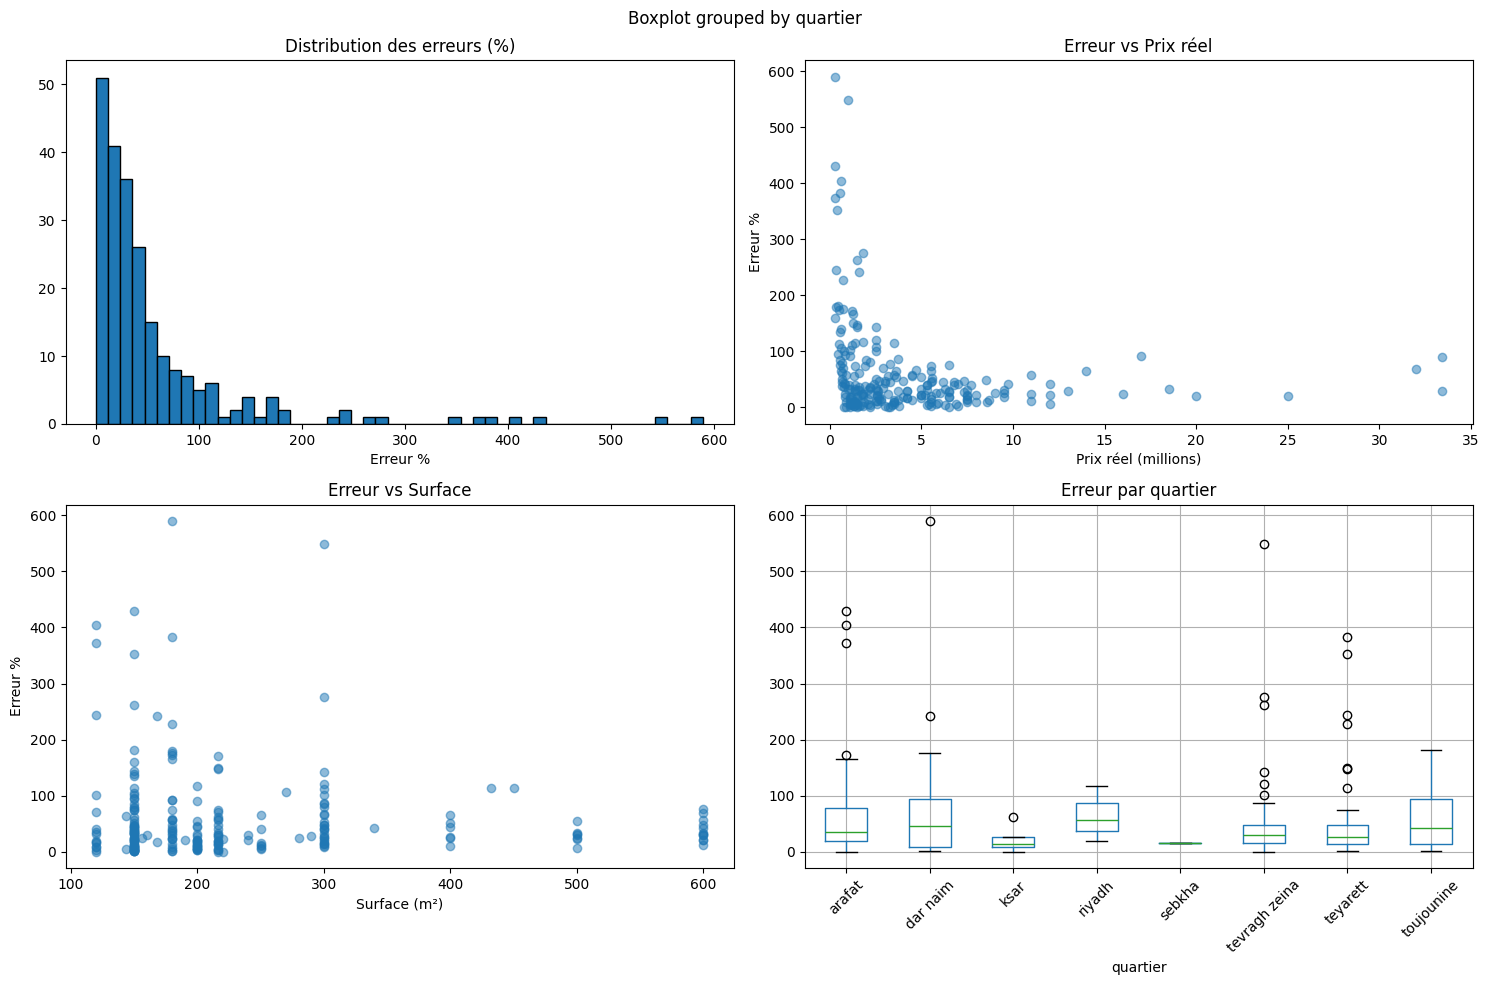

In [24]:
# ============================================
# ÉTAPE 5c: PIRES PRÉDICTIONS
# ============================================

print("\n🔴 TOP 20 DES PIRES PRÉDICTIONS:")
pires = error_analysis.nlargest(20, 'erreur_pct')[['prix_reel', 'prix_pred', 'erreur_pct', 'quartier', 'type_bien']]
print(pires.to_string())

# Visualisation
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Distribution des erreurs
axes[0, 0].hist(error_analysis['erreur_pct'], bins=50, edgecolor='black')
axes[0, 0].set_title('Distribution des erreurs (%)')
axes[0, 0].set_xlabel('Erreur %')

# Erreur vs Prix réel
axes[0, 1].scatter(error_analysis['prix_reel']/1e6, error_analysis['erreur_pct'], alpha=0.5)
axes[0, 1].set_xlabel('Prix réel (millions)')
axes[0, 1].set_ylabel('Erreur %')
axes[0, 1].set_title('Erreur vs Prix réel')

# Erreur vs Surface
axes[1, 0].scatter(error_analysis['surface'], error_analysis['erreur_pct'], alpha=0.5)
axes[1, 0].set_xlabel('Surface (m²)')
axes[1, 0].set_ylabel('Erreur %')
axes[1, 0].set_title('Erreur vs Surface')

# Boxplot par quartier
error_analysis.boxplot(column='erreur_pct', by='quartier', ax=axes[1, 1])
axes[1, 1].set_title('Erreur par quartier')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('error_analysis.png', dpi=150)
plt.show()

In [26]:
# ============================================
# CORRECTION - APPLICATION DES TRANSFORMATIONS AU TEST
# ============================================

print("=" * 70)
print("🔧 APPLICATION DES TRANSFORMATIONS AU TEST")
print("=" * 70)

# 1. Copier le test
df_test_processed = df_test.copy()

# ============================================
# 1. FEATURES TEMPORELLES
# ============================================
print("\n📅 1. Création des features temporelles...")

df_test_processed['date_publication'] = pd.to_datetime(df_test_processed['date_publication'])
df_test_processed['mois'] = df_test_processed['date_publication'].dt.month
df_test_processed['trimestre'] = df_test_processed['date_publication'].dt.quarter
df_test_processed['annee'] = df_test_processed['date_publication'].dt.year
print("✅ mois, trimestre, annee créés")

# ============================================
# 2. RATIOS INTELLIGENTS
# ============================================
print("\n📊 2. Création des ratios...")

df_test_processed['surface_par_piece'] = df_test_processed['surface_m2'] / (df_test_processed['nb_pieces_total'] + 1)
df_test_processed['surface_par_chambre'] = df_test_processed['surface_m2'] / (df_test_processed['nb_chambres'] + 1)
print("✅ surface_par_piece, surface_par_chambre créés")

# ============================================
# 3. INTERACTIONS GÉOGRAPHIQUES
# ============================================
print("\n🗺️ 3. Création des interactions géographiques...")

df_test_processed['pois_density_centre'] = df_test_processed['nb_total_pois_1km'] / (df_test_processed['dist_centre_ville_km'] + 0.1)
df_test_processed['pois_density_plage'] = df_test_processed['nb_total_pois_1km'] / (df_test_processed['dist_plage_km'] + 0.1)
df_test_processed['centre_x_plage'] = df_test_processed['dist_centre_ville_km'] * df_test_processed['dist_plage_km']
print("✅ pois_density_centre, pois_density_plage, centre_x_plage créés")

# ============================================
# 4. SCORE D'ÉQUIPEMENT
# ============================================
print("\n🔧 4. Création du score d'équipement...")

df_test_processed['score_equipement'] = (df_test_processed['has_garage'] + df_test_processed['has_jardin'] + 
                                         df_test_processed['has_piscine'] + df_test_processed['has_balcon'] + 
                                         df_test_processed['has_meuble'] + df_test_processed['has_titre_foncier'])
print("✅ score_equipement créé")

# ============================================
# 5. ENCODAGE TYPE_BIEN
# ============================================
print("\n🏠 5. Encodage du type de bien...")

if 'type_bien' in df_test_processed.columns:
    type_dummies_test = pd.get_dummies(df_test_processed['type_bien'], prefix='type', drop_first=True)
    df_test_processed = pd.concat([df_test_processed, type_dummies_test], axis=1)
    print(f"✅ {len(type_dummies_test.columns)} colonnes type_* créées")

# ============================================
# 6. STATISTIQUES PAR QUARTIER (depuis TRAIN)
# ============================================
print("\n🏘️ 6. Ajout des statistiques par quartier (depuis TRAIN)...")

# Calculer les moyennes par quartier sur TRAIN
quartier_means = df_train.groupby('quartier').agg({
    'surface_m2': 'mean',
    'nb_pieces_total': 'mean',
    'nb_total_pois_1km': 'mean',
    'age_annonce': 'mean'
}).round(2)

# Renommer les colonnes
quartier_means.columns = ['surface_moy_quartier', 'pieces_moy_quartier', 
                          'pois_moy_quartier', 'age_moy_quartier']

# Ajouter au test
for col in quartier_means.columns:
    df_test_processed[col] = df_test_processed['quartier'].map(quartier_means[col])

# Ajouter aussi le nombre de biens par quartier
nb_biens = df_train.groupby('quartier').size()
df_test_processed['nb_biens_quartier'] = df_test_processed['quartier'].map(nb_biens)

print("✅ Statistiques quartier ajoutées")

# ============================================
# 7. GÉRER LES VALEURS MANQUANTES
# ============================================
print("\n🔄 7. Gestion des valeurs manquantes...")

# Remplir les NaN avec la médiane de TRAIN
for col in quartier_means.columns:
    median_val = quartier_means[col].median()
    df_test_processed[col] = df_test_processed[col].fillna(median_val)

df_test_processed['nb_biens_quartier'] = df_test_processed['nb_biens_quartier'].fillna(nb_biens.median())

print("✅ Valeurs manquantes traitées")

# ============================================
# 8. VÉRIFICATION FINALE
# ============================================
print("\n🔍 8. Vérification des features...")

# Features utilisées par le modèle
feature_cols = X.columns.tolist()

# Vérifier les colonnes manquantes
missing_cols = [col for col in feature_cols if col not in df_test_processed.columns]
if missing_cols:
    print(f"\n⚠️ Colonnes encore manquantes: {missing_cols}")
    for col in missing_cols:
        df_test_processed[col] = 0
        print(f"   → {col} créée avec 0")
else:
    print("✅ Toutes les colonnes sont présentes !")

# Préparer X_test
X_test_final = df_test_processed[feature_cols]
print(f"\n📊 X_test final prêt: {X_test_final.shape}")

🔧 APPLICATION DES TRANSFORMATIONS AU TEST

📅 1. Création des features temporelles...
✅ mois, trimestre, annee créés

📊 2. Création des ratios...
✅ surface_par_piece, surface_par_chambre créés

🗺️ 3. Création des interactions géographiques...
✅ pois_density_centre, pois_density_plage, centre_x_plage créés

🔧 4. Création du score d'équipement...
✅ score_equipement créé

🏠 5. Encodage du type de bien...
✅ 3 colonnes type_* créées

🏘️ 6. Ajout des statistiques par quartier (depuis TRAIN)...
✅ Statistiques quartier ajoutées

🔄 7. Gestion des valeurs manquantes...
✅ Valeurs manquantes traitées

🔍 8. Vérification des features...
✅ Toutes les colonnes sont présentes !

📊 X_test final prêt: (289, 32)


In [27]:
# ============================================
# PRÉDICTIONS SUR TEST
# ============================================

print("\n" + "=" * 70)
print("🔮 PRÉDICTIONS SUR TEST")
print("=" * 70)

# Utiliser le meilleur modèle (ex: Random Forest)
best_model = models['RF']  # ou celui qui a le meilleur score
predictions = best_model.predict(X_test_final)
predictions = np.maximum(predictions, 0)

print(f"\n💰 Statistiques des prédictions:")
print(f"   Min: {predictions.min():,.0f} MRU")
print(f"   Max: {predictions.max():,.0f} MRU")
print(f"   Moyenne: {predictions.mean():,.0f} MRU")

# Créer soumission
submission = pd.DataFrame({
    'id': df_test['id'],
    'prix': predictions.round(0).astype(int)
})

submission.to_csv('submission_finale.csv', index=False)
print(f"\n✅ Soumission sauvegardée: 'submission6.csv'")
print(submission.head(10).to_string(index=False))


🔮 PRÉDICTIONS SUR TEST

💰 Statistiques des prédictions:
   Min: 714,324 MRU
   Max: 19,643,153 MRU
   Moyenne: 4,047,238 MRU

✅ Soumission sauvegardée: 'submission6.csv'
  id    prix
 528 2183330
1296 1578226
1286 1334897
1021 1016323
  64 1913686
 864 8512930
 618 1650507
1017 4414582
1235 1643574
 588 7422062


In [ ]:
# ============================================
# PROCHAINE SOUMISSION - POUR PASSER 5ÈME
# ============================================

# Option 1: Optimiser Random Forest
rf_best = RandomForestRegressor(
    n_estimators=300,
    max_depth=12,
    min_samples_split=5,
    random_state=42
)

# Option 2: XGBoost avec tuning
xgb_best = xgb.XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

# Option 3: Moyenne des 3 meilleurs
# final_pred = (gb_pred * 0.3 + rf_pred * 0.4 + xgb_pred * 0.3)